# modele

Features utilisées :
['heures_etude', 'genre', 'assiduité_classe', 'heures_sommeil', 'qualité_sommeil', 'évaluation_établissement', 'accès_internet', 'diplôme_Engineering', 'diplôme_Marketing', 'diplôme_Computer Science']

Shape X : (630000, 10)
Shape y : (630000,)

===== BASELINE =====
MAE  : 15.545894418150164
RMSE : 18.897375422654083
R2   : -4.240951068457122e-05

===== RANDOM FOREST =====
MAE  : 8.052266883404446
RMSE : 10.172075900785401
R2   : 0.7102425440228539

===== FEATURE IMPORTANCE =====
heures_etude                0.631429
assiduité_classe            0.177121
heures_sommeil              0.079489
qualité_sommeil             0.039235
évaluation_établissement    0.027049
genre                       0.010795
accès_internet              0.009327
diplôme_Engineering         0.008843
diplôme_Computer Science    0.008425
diplôme_Marketing           0.008289
dtype: float64


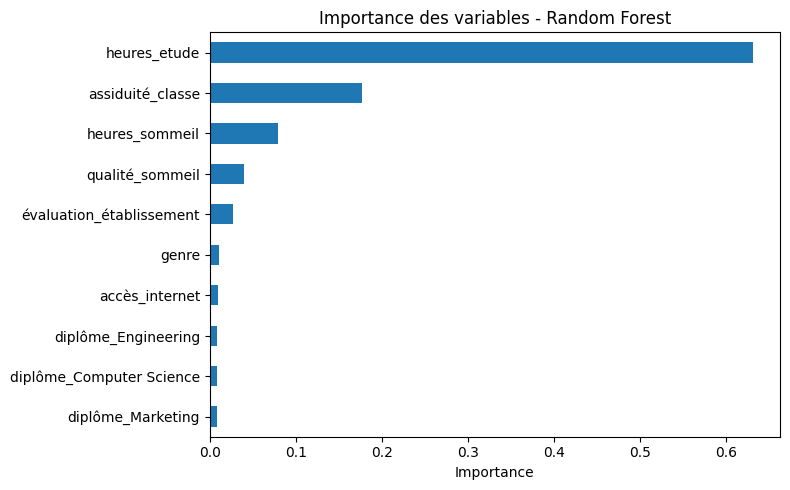

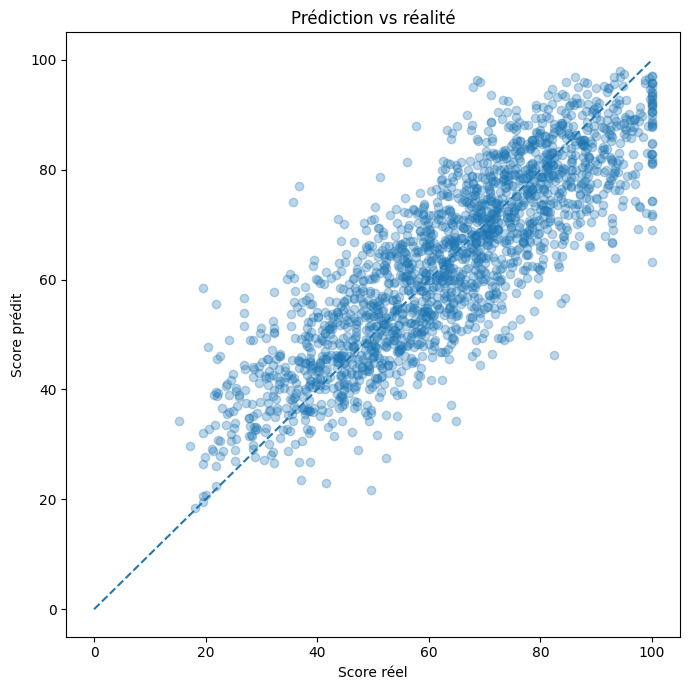

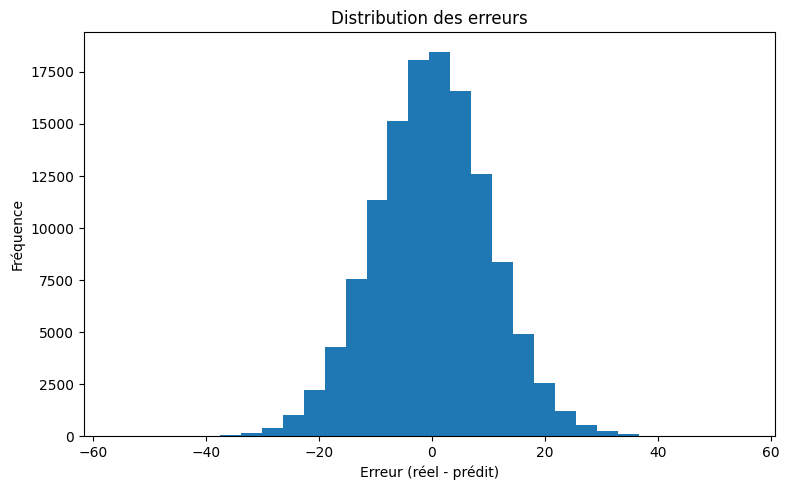


===== RANDOM FOREST FULL =====
MAE  : 7.5932416272222225
RMSE : 9.584267078245471
R2   : 0.7427631098340284

===== COMPARAISON =====
                   Model        MAE       RMSE        R2
0               Baseline  15.545894  18.897375 -0.000042
1  RandomForest_Selected   8.052267  10.172076  0.710243
2      RandomForest_Full   7.593242   9.584267  0.742763


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

# =========================================================
# 1. CHARGEMENT
# =========================================================
df = pd.read_csv(r"student_dataset/student_failure/train.csv")

# =========================================================
# 2. COPIE + PREPROCESSING DE BASE
# =========================================================
df_ml = df.copy()

# supprimer id
df_ml = df_ml.drop(columns=["id"])

# -------------------------
# suppression des doublons
# -------------------------
n_before = len(df_ml)
df_ml = df_ml.drop_duplicates()
print(f"Doublons supprimés : {n_before - len(df_ml)} (reste {len(df_ml)} lignes)")

# -------------------------
# gestion des NaN
# -------------------------
num_cols = df_ml.select_dtypes(include=np.number).columns
cat_cols = df_ml.select_dtypes(include="object").columns

df_ml[num_cols] = df_ml[num_cols].fillna(df_ml[num_cols].mean())
df_ml[cat_cols] = df_ml[cat_cols].fillna("unknown")

# -------------------------
# encoding
# -------------------------

# binaire
df_ml["genre"] = df_ml["genre"].map({"male": 0, "female": 1}).fillna(0)
df_ml["accès_internet"] = df_ml["accès_internet"].map({"yes": 1, "no": 0}).fillna(0)

# ordinal
df_ml["qualité_sommeil"] = df_ml["qualité_sommeil"].map({
    "poor": 0,
    "average": 1,
    "good": 2,
    "excellent": 3
}).fillna(1)

df_ml["évaluation_établissement"] = df_ml["évaluation_établissement"].map({
    "low": 0,
    "medium": 1,
    "high": 2
}).fillna(1)

df_ml["difficulté_examen"] = df_ml["difficulté_examen"].map({
    "easy": 0,
    "moderate": 1,
    "hard": 2
}).fillna(1)

# nominal
df_ml = pd.get_dummies(
    df_ml,
    columns=["diplôme", "méthode_etude"],
    drop_first=True
)

# convertir bool -> float
df_ml = df_ml.astype(float)

# =========================================================
# 3. VARIABLES SELECTIONNEES (issues de ton autre notebook)
# =========================================================
selected_features = [
    "heures_etude",
    "genre",
    "assiduité_classe",
    "heures_sommeil",
    "qualité_sommeil",
    "évaluation_établissement",
    "accès_internet",
    "diplôme_Engineering",
    "diplôme_Marketing",
    "diplôme_Computer Science"
]

# sécurité si une colonne manque
selected_features = [col for col in selected_features if col in df_ml.columns]

X = df_ml[selected_features]
y = df_ml["score_examen"]

print("Features utilisées :")
print(X.columns.tolist())
print("\nShape X :", X.shape)
print("Shape y :", y.shape)

# =========================================================
# 4. TRAIN / TEST SPLIT
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# =========================================================
# 5. BASELINE SIMPLE
# =========================================================
baseline_pred = np.full(len(y_test), y_train.mean())

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_r2 = r2_score(y_test, baseline_pred)

print("\n===== BASELINE =====")
print("MAE  :", baseline_mae)
print("RMSE :", baseline_rmse)
print("R2   :", baseline_r2)

# =========================================================
# 6. MODELE RANDOM FOREST
# =========================================================
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

preds = model.predict(X_test)

mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

print("\n===== RANDOM FOREST =====")
print("MAE  :", mae)
print("RMSE :", rmse)
print("R2   :", r2)

# =========================================================
# 7. FEATURE IMPORTANCE
# =========================================================
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

print("\n===== FEATURE IMPORTANCE =====")
print(importances)

plt.figure(figsize=(8, 5))
importances.sort_values().plot(kind="barh")
plt.title("Importance des variables - Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

# =========================================================
# 8. PREDICTION VS REALITE
# =========================================================
sample_idx = np.random.choice(len(y_test), size=2000, replace=False) if len(y_test) > 2000 else np.arange(len(y_test))

plt.figure(figsize=(7, 7))
plt.scatter(y_test.iloc[sample_idx], preds[sample_idx], alpha=0.3)
plt.xlabel("Score réel")
plt.ylabel("Score prédit")
plt.title("Prédiction vs réalité")
plt.plot([0, 100], [0, 100], linestyle="--")
plt.tight_layout()
plt.show()

# =========================================================
# 9. ERREURS
# =========================================================
errors = y_test - preds

plt.figure(figsize=(8, 5))
plt.hist(errors, bins=30)
plt.title("Distribution des erreurs")
plt.xlabel("Erreur (réel - prédit)")
plt.ylabel("Fréquence")
plt.tight_layout()
plt.show()

# =========================================================
# 10. VERSION FULL POUR COMPARAISON
# =========================================================
X_full = df_ml.drop(columns=["score_examen"])
y_full = df_ml["score_examen"]

Xf_train, Xf_test, yf_train, yf_test = train_test_split(
    X_full, y_full,
    test_size=0.2,
    random_state=42
)

model_full = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model_full.fit(Xf_train, yf_train)
preds_full = model_full.predict(Xf_test)

mae_full = mean_absolute_error(yf_test, preds_full)
rmse_full = np.sqrt(mean_squared_error(yf_test, preds_full))
r2_full = r2_score(yf_test, preds_full)

print("\n===== RANDOM FOREST FULL =====")
print("MAE  :", mae_full)
print("RMSE :", rmse_full)
print("R2   :", r2_full)

# =========================================================
# 11. COMPARAISON FINALE
# =========================================================
results = pd.DataFrame({
    "Model": ["Baseline", "RandomForest_Selected", "RandomForest_Full"],
    "MAE": [baseline_mae, mae, mae_full],
    "RMSE": [baseline_rmse, rmse, rmse_full],
    "R2": [baseline_r2, r2, r2_full]
})

print("\n===== COMPARAISON =====")
print(results)


# Decision tree

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

tree_model = DecisionTreeRegressor(max_leaf_nodes=100, random_state=1)
tree_model.fit(Xf_train, yf_train)

y_pred_tree = tree_model.predict(Xf_test)

mae_tree = mean_absolute_error(yf_test, y_pred_tree)
rmse_tree = np.sqrt(mean_squared_error(yf_test, y_pred_tree))
r2_tree = r2_score(yf_test, y_pred_tree)

print("===== DECISION TREE =====")
print("MAE  :", mae_tree)
print("RMSE :", rmse_tree)
print("R2   :", r2_tree)

===== DECISION TREE =====
MAE  : 8.516669655805032
RMSE : 10.668576232698776
R2   : 0.6812660202346761


# linear regression

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

ridge = Ridge(alpha=1.0)
ridge.fit(Xf_train, yf_train)

y_pred_ridge = ridge.predict(Xf_test)

mae_ridge = mean_absolute_error(yf_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(yf_test, y_pred_ridge))
r2_ridge = r2_score(yf_test, y_pred_ridge)

print("===== RIDGE REGRESSION =====")
print("MAE  :", mae_ridge)
print("RMSE :", rmse_ridge)
print("R2   :", r2_ridge)

===== RIDGE REGRESSION =====
MAE  : 7.359399115615735
RMSE : 9.28652605056605
R2   : 0.7584972955695692


# Deep learning 

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =========================================================
# 1. SCALING
# =========================================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(Xf_train)
X_test_scaled = scaler.transform(Xf_test)

# =========================================================
# 2. MODELE DEEP LEARNING SIMPLE
# =========================================================
model_dl = keras.Sequential([
    layers.Dense(32, activation='relu', input_shape=[X_train_scaled.shape[1]]),
    layers.Dense(16, activation='relu'),
    layers.Dense(1)
])

model_dl.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

# =========================================================
# 3. ENTRAINEMENT
# =========================================================
history = model_dl.fit(
    X_train_scaled, yf_train,
    validation_split=0.2,
    epochs=20,
    batch_size=256,
    verbose=1
)

# =========================================================
# 4. PREDICTIONS
# =========================================================
preds_dl = model_dl.predict(X_test_scaled).flatten()

mae_dl = mean_absolute_error(yf_test, preds_dl)
rmse_dl = np.sqrt(mean_squared_error(yf_test, preds_dl))
r2_dl = r2_score(yf_test, preds_dl)

print("===== DEEP LEARNING =====")
print("MAE  :", mae_dl)
print("RMSE :", rmse_dl)
print("R2   :", r2_dl)

C:\Users\louis\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - loss: 524.9205 - mae: 14.6130 - val_loss: 99.4503 - val_mae: 7.9261
Epoch 2/20
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 95.3759 - mae: 7.7619 - val_loss: 93.7174 - val_mae: 7.6845
Epoch 3/20
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 92.1738 - mae: 7.6290 - val_loss: 91.6634 - val_mae: 7.5977
Epoch 4/20
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 90.5858 - mae: 7.5618 - val_loss: 90.2130 - val_mae: 7.5371
Epoch 5/20
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 89.2182 - mae: 7.5046 - val_loss: 89.3531 - val_mae: 7.5058
Epoch 6/20
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 88.2222 - mae: 7.4621 - val_loss: 88.3813 - val_mae: 7.4614
Epoch 7/20
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 87.5893 - mae: 7.4355 - val_loss: 87.8204 - val_mae: 7.4424
Epoch 8/20
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 87.1645 - mae: 7.4171 - val_loss: 87.5870 - val_mae: 7.4271
Epoch 9/20
1575/1575 ━


===== FINAL COMPARISON =====
                      Model        MAE       RMSE        R2
4          Ridge Regression   7.359399   9.286526  0.758497
5       Deep Learning (MLP)   7.384738   9.317092  0.756905
3      Random Forest (Full)   7.593242   9.584267  0.742763
2  Random Forest (Selected)   8.052267  10.172076  0.710243
1             Decision Tree   8.516670  10.668576  0.681266
0                  Baseline  15.545894  18.897375 -0.000042


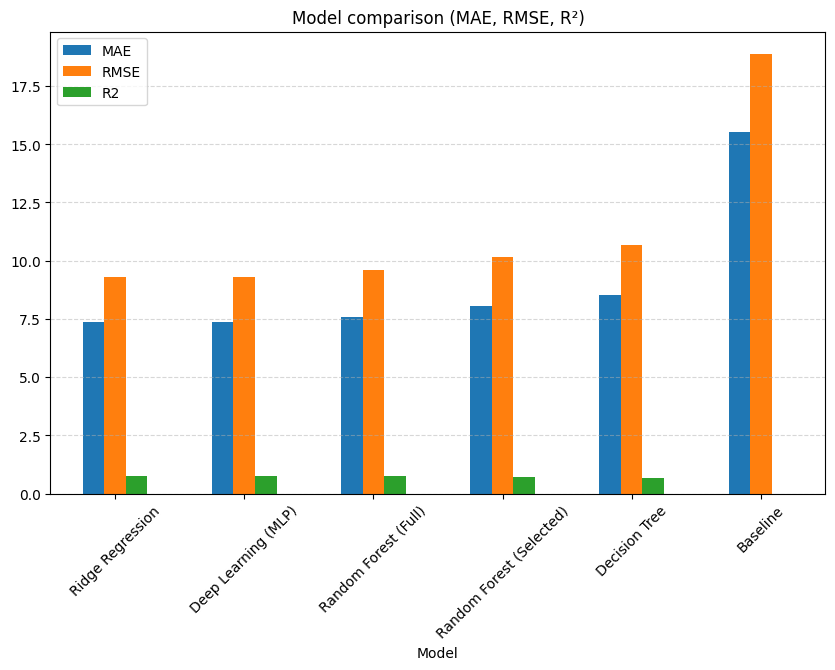

In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Baseline",
        "Decision Tree",
        "Random Forest (Selected)",
        "Random Forest (Full)",
        "Ridge Regression",
        "Deep Learning (MLP)"
    ],
    "MAE": [
        baseline_mae,
        mae_tree,
        mae,
        mae_full,
        mae_ridge,
        mae_dl
    ],
    "RMSE": [
        baseline_rmse,
        rmse_tree,
        rmse,
        rmse_full,
        rmse_ridge,
        rmse_dl
    ],
    "R2": [
        baseline_r2,
        r2_tree,
        r2,
        r2_full,
        r2_ridge,
        r2_dl
    ]
})

results = results.sort_values(by="R2", ascending=False)

print("\n===== FINAL COMPARISON =====")
print(results)

import matplotlib.pyplot as plt

results_plot = results.set_index("Model")

results_plot.plot(kind="bar", figsize=(10,6))
plt.title("Model comparison (MAE, RMSE, R²)")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

